## This is a sample Machine Learning project that exemplifies how to proceed Count Data Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Tabulate, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import exp, factorial
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP,ZeroInflatedPoisson
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf
from tqdm import tqdm
from statstests.tests import overdisp
from scipy import stats
from scipy.interpolate import interp1d
from tabulate import tabulate
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import os
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - Violations = f(staff, post, corruption). Negative Binomial or Poisson Gama Regression - Count Data.

This is a simple use-case for Generalized Linear Models (GLMs) of type Negative Binomial or Poisson Gama Regression for Count Data or Rate Data (NB). For other Count Data regression types (e.g. PR, ZIP, ZINB), see other examples at this same project directory. Here, we reuse the same dataset already used at the Poisson Regression (PR), and this dataset is actually being reused in all four use-cases at this directory. So, if you wanna read more about it, or about Regression Analysis for Count Data fundamentals, check out the first project, about Poisson Regression (PR) [here](./regression-analysis-count-data-poisson-violations.ipynb).

The key difference between the standard Poisson model and the Poisson–Gamma (Negative Binomial) model lies in how variability is treated, and this requires clearly distinguishing between Yᵢ, Ŷᵢ, and λᵢ:

- Yᵢ is the observed count (the realized integer number of violations for an observation). It is not a mean or a prediction.
- Ŷᵢ is a single number (not necessarily an integer) that represents the mean (expected value) of the Poisson distribution associated with the observation. It is not a specific observed or predicted m count, but the weighted average over all possible outcomes m defined by the PMF, along the respective probabilities, at each observation.
- λᵢ is the conditional mean parameter of the Poisson distribution. In Poisson regression, we have Ŷᵢ = λᵢ. The most probable count (the mode) is typically an integer near λᵢ (often ⌊λᵢ⌋). Therefore, values of m close to λᵢ have higher probabilities in the PMF for each observation.

In a standard Poisson model, conditional on the predictors Xᵢ, λᵢ is fixed (i.e., Var(λᵢ) = 0 within the model). The randomness comes only from Yᵢ given λᵢ:

E(Yᵢ | λᵢ) = λᵢ  
Var(Yᵢ | λᵢ) = λᵢ  

Thus, the variance of Yᵢ equals its mean, implying equidispersion. The spread of possible m values (realizations of Yᵢ) is entirely governed by the Poisson distribution centered at λᵢ.

However, in many real datasets, the observed variability in Yᵢ exceeds what the Poisson model allows. This is overdispersion. The Negative Binomial (Poisson Gama) model addresses this by allowing λᵢ itself to vary across observations due to unobserved heterogeneity. In other words, λᵢ is treated as a random variable:

λᵢ ~ Gamma(mean = μᵢ, variance = αμᵢ²)

Now, Yᵢ is conditionally Poisson given λᵢ, but λᵢ varies across observations. Applying the law of total expectation and variance:

E(Yᵢ) = E[ E(Yᵢ | λᵢ) ] = E(λᵢ) = μᵢ  
Var(Yᵢ) = E[ Var(Yᵢ | λᵢ) ] + Var[ E(Yᵢ | λᵢ) ]  
         = E(λᵢ) + Var(λᵢ)  
         = μᵢ + αμᵢ²  

The second term, αμᵢ², captures the extra variability (overdispersion). It arises not from the Poisson mechanism itself, but from variability in λᵢ across observations.

Therefore:
- Yᵢ is the realized count (random outcome)
- Ŷᵢ = λᵢ is the predicted mean
- In Poisson: λᵢ is fixed given Xᵢ → Var(Yᵢ) = E(Yᵢ)
- In Negative Binomial: λᵢ varies → Var(Yᵢ) > E(Yᵢ)

This additional variability allows the model to better capture the heavier right tail (more extreme counts), often resulting in improved fit (e.g., higher log-likelihood values).

It is not the mean of Yi (μi = λi) that varies for the same predictors' values (Xi), across observations... the center mean is fixed, both in Poisson as in Poisson Gama. What varies in Poisson Gama is the spread (variance) of Yi observed values, at each same observation, around the same fixed centered mean. The μi = λi is the same (for same predictors' values), the observed values is that distanciate further from the mean, because of overdispersion.

The Cameron and Trivedi is the test to prove statistically if the mean of Yi is equal to or less than the variance of Yi, i.e., if we have equidispersion or overdispersion in our data, and whether we should use Poisson or Poisson Gama distributions when defining our model.

The zero-inflation analyis is done on the 3rd and 4th examples at this same directory. Another test is needed for that. We're not considering zero-inflation here, only the overdispersion.

![./poisson-gama.png](./poisson-gama.png)

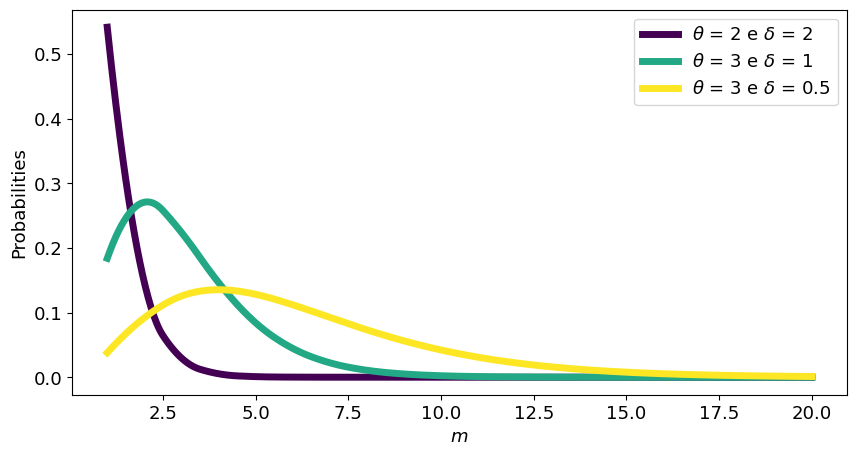

In [2]:
# creating sample Probability Mass Function (PMF) Poisson Gama distributions, for different theta and delta
# θ is called the shape parameter (θ > 0). Thetha (θ) is the inverse of phi (φ), also known as alfa (another alfa, 
# other than the model intercept), and δ is called the decay rate parameter (δ > 0), which incorporates the lambdai 
# (or μi), as delta (δ) = theta (θ) / lambdai (μi).

# defining a PMF Poisson Gama distribution function (see formula at the above picture), based on a custom theta and 
# delta - that define the Distribution - and an m value, whose probability of happening we wish to know, as the 
# function result. We use this function to calculate multiple sample m probabilities and plot the PMF graph. Or we 
# could use it to calculate the probability for any particular m at a concrete problem (if using the theta and delta 
# of the problem), including the prob for the mean of m(s), i.e., the prob for lambda. Lambdai still exists, also 
# called μi, although for some of the formulas above it is not used directly, and is incorporated at the delta (δ): 
# for instance, at the formula below - unless it is considered the m whose probability we want to know.
def bneg(theta, delta, m):
    return ((delta ** theta) * (m ** (theta - 1)) * (exp(-m * delta))) / factorial(theta - 1)

# plotting different Poisson Gama PMFs for 3 different sample theta and lambda. This is a simple demonstration of 
# random theta ans delta Poisson Gama PMFs distributions and have nothing to do with our dataset. For our actual 
# dataset, we'll plot different PMFs later, when we calculate the actual lambda from the predictors (at each 
# observation)
m = np.arange(1,21)
bneg_theta2_delta2 = []
bneg_theta3_delta1 = []
bneg_theta3_delta05 = []

for item in m:
    bneg_theta2_delta2.append(bneg(2,2,item))
    bneg_theta3_delta1.append(bneg(3,1,item))
    bneg_theta3_delta05.append(bneg(3,0.5,item))
   
# putting those pmf results into a df
neg_binom_df = pd.DataFrame({'m':m,
                        'bneg_theta2_delta2':bneg_theta2_delta2,
                        'bneg_theta3_delta1':bneg_theta3_delta1,
                        'bneg_theta3_delta05':bneg_theta3_delta05})

# plotting the df into a graph
def smooth_line_plot(x,y):
    x_new = np.linspace(x.min(), x.max(),500)
    f = interp1d(x, y, kind='quadratic')
    y_smooth=f(x_new)
    return x_new, y_smooth

x_new, bneg_theta2_delta2 = smooth_line_plot(neg_binom_df.m,
                                             neg_binom_df.bneg_theta2_delta2)
x_new, bneg_theta3_delta1 = smooth_line_plot(neg_binom_df.m,
                                             neg_binom_df.bneg_theta3_delta1)
x_new, bneg_theta3_delta05 = smooth_line_plot(neg_binom_df.m,
                                              neg_binom_df.bneg_theta3_delta05)

plt.figure(figsize=(10,5))
plt.plot(x_new,bneg_theta2_delta2, linewidth=5, color='#440154FF')
plt.plot(x_new,bneg_theta3_delta1, linewidth=5, color='#22A884FF')
plt.plot(x_new,bneg_theta3_delta05, linewidth=5, color='#FDE725FF')
plt.xlabel('m', fontsize=13, style='italic')
plt.ylabel('Probabilities', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend([r'$\theta$ = 2 e $\delta$ = 2',
            r'$\theta$ = 3 e $\delta$ = 1',
            r'$\theta$ = 3 e $\delta$ = 0.5'],
           fontsize=13)
plt.show()

In [3]:
# loading dataset
corruption_df = pd.read_csv('corruption.csv', delimiter=',')

In [4]:
# estimating the neg binomial model
neg_binomial_model = sm.NegativeBinomial.from_formula('violations ~ staff + post + corruption',
                                               data=corruption_df).fit()
neg_binomial_model.summary()

# the alfa param here is not the intercept, but the dispersion parameter, also called phi (φ)

# observe also that, for the same dataset, we had a substancial improvement on the Log-Likelihood (ll) value (-567.40) 
# of this Poisson Gama model when compared to the ll of the traditional Poisson model (-2071.8), that we calculated on
# the first example project, and this reflects how better the current model has fit the data for greater predictivity 
# (including the positive outliers - right skewness).

Optimization terminated successfully.
         Current function value: 1.904031
         Iterations: 19
         Function evaluations: 23
         Gradient evaluations: 23


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:             violations   No. Observations:                  298
Model:               NegativeBinomial   Df Residuals:                      294
Method:                           MLE   Df Model:                            3
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.1549
Time:                        23:00:42   Log-Likelihood:                -567.40
converged:                       True   LL-Null:                       -671.37
Covariance Type:            nonrobust   LLR p-value:                 8.088e-45
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.9469      0.205      9.477      0.000       1.544       2.350
post[T.yes]    -4.2746      0.266    -16.065      0.000      -4.796      -3.753
staff           0.0400      0.014      2.945      0.003       0.013       0.067
corruption      0.4527      0.133      3.396      0.001       0.191       0.714
alpha           2.0963      0.243      8.614      0.000       1.619       2.573
===============================================================================
"""

In [5]:
# calculating optimum phi (φ) for best Log-Likelihood (ll):

alphas = np.linspace(0, 10, 2000)
llf = np.full(len(alphas), np.nan)
for i, alpha in tqdm(enumerate(alphas), total=len(alphas)):
    try:
        res = smf.glm(
            'violations ~ staff + post + corruption',
            data=corruption_df,
            family=sm.families.NegativeBinomial(alpha=alpha)
        ).fit()
        llf[i] = res.llf
    except:
        pass
optimum_fi = alphas[np.nanargmax(llf)]
float(optimum_fi.round(3))

# observe it's the same phi (alfa) defined at the model above, thus the ll of the current model is really maximum

100%|██████████████████████████████████████| 2000/2000 [00:19<00:00, 104.22it/s]


2.096

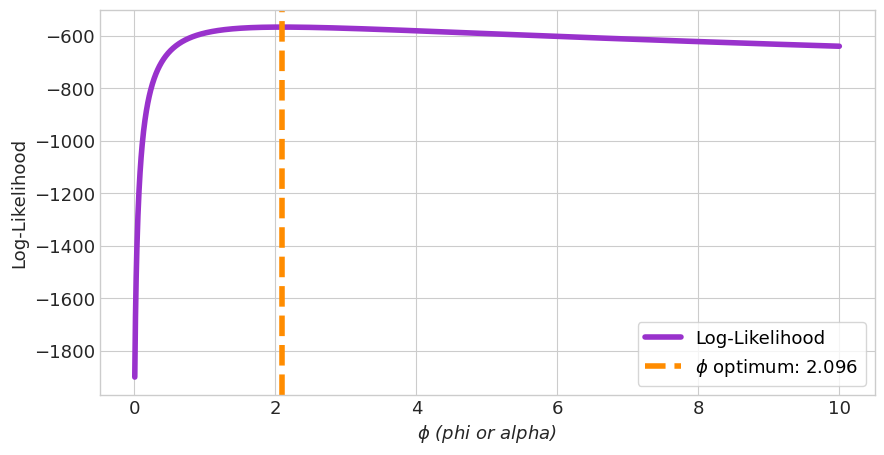

In [6]:
# Plotting Log-likelihood x phi (φ)

plt.figure(figsize=(10, 5))
with plt.style.context('seaborn-v0_8-whitegrid'):
    plt.plot(alphas, llf, label='Log-Likelihood',
             color='darkorchid', linewidth = 4)
    plt.axvline(x=optimum_fi, color='darkorange',
                linewidth = 4, linestyle='dashed',
            label=f'$\\phi$ optimum: {round(optimum_fi, 3)}')
plt.xlabel('$\\phi$ (phi or alpha)', fontsize=13, style='italic')
plt.ylabel('Log-Likelihood', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(loc='lower right', fontsize=13)
plt.show()

In [7]:
# comparing the first model - classic Poisson - with this current Poisson Gama model

# redefining the classical Poisson model again for comparation with the Poisson Gama current model
poisson_model = sm.Poisson.from_formula('violations ~ staff + post + corruption',
                                         data=corruption_df).fit()

# Comparing models: Poisson e Poisson Gama (Negative Binomial)

summary_col([poisson_model, neg_binomial_model], 
            model_names=["Poisson","NegBinom"],
            stars=True,
            info_dict = {
                'N':lambda x: "{0:d}".format(int(x.nobs)),
                'Log-lik':lambda x: "{:.2f}".format(x.llf)
                })

Optimization terminated successfully.
         Current function value: 6.952328
         Iterations 9


,Poisson,NegBinom
Intercept,2.2127***,1.9469***
,(0.0311),(0.2054)
post[T.yes],-4.2968***,-4.2746***
,(0.1974),(0.2661)
staff,0.0219***,0.0400***
,(0.0012),(0.0136)
corruption,0.3418***,0.4527***
,(0.0275),(0.1333)
alpha,,2.0963***
,,(0.2434)


In [8]:
# Defining function for LLR testing of two models

def lrtest(models):
    model_1 = models[0]
    llk_1 = model_1.llnull
    llk_2 = model_1.llf
    
    if len(models)>1:
        llk_1 = model_1.llf
        llk_2 = models[1].llf
    LR_statistic = -2*(llk_1-llk_2)
    p_val = stats.chi2.sf(LR_statistic, 1) # 1 degree of freedom
    
    print("Likelihood Ratio Test:")
    print(f"-2.(LL0-LLm): {round(LR_statistic, 2)}")
    print(f"p-value: {p_val:.3f}")
    print("")
    print("==================Result======================== \n")
    if p_val <= 0.05:
        print("H1: Different models, favoring the one with the highest Log-Likelihood")
    else:
        print("H0: Models with log-likelihoods that are not statistically different at 95% confidence level")

# Testing LLD between negative binomial model and classic Poisson model
lrtest([poisson_model, neg_binomial_model])

# Observe that the chi2 test between the two models has proved they're different, in terms of llf value, and therefore
# the one with highest llf value (Poisson Gama ll=-567.40) is the best model so far.

Likelihood Ratio Test:
-2.(LL0-LLm): 3008.79
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


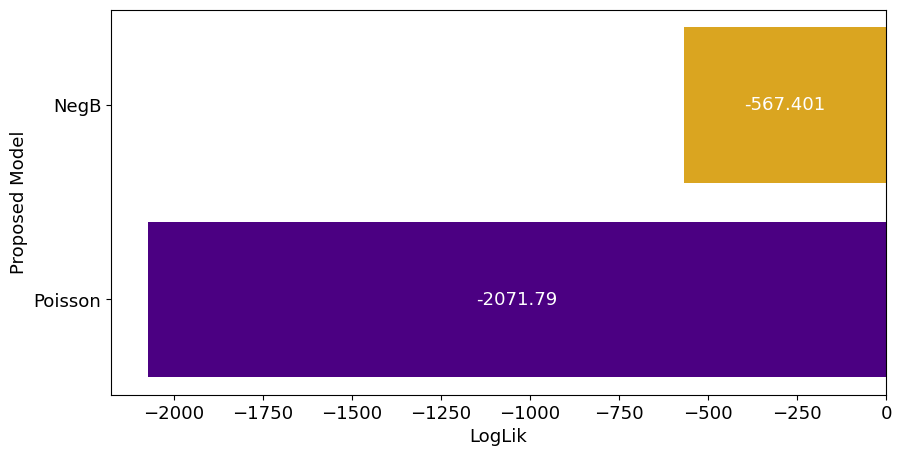

In [9]:
# LogLiks comparation graph of classic Poisson and Poisson Gama (negative binomial) models

df_llf = pd.DataFrame({'model':['Poisson','NegB'],
                      'loglik':[poisson_model.llf, neg_binomial_model.llf]})
df_llf

fig, ax = plt.subplots(figsize=(10,5))

c = ['indigo', 'goldenrod']

ax1 = ax.barh(df_llf.model,df_llf.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [10]:
# Doing some predictions with the classic Poisson and Poisson Gama models

# How many in average would be the number of parking violations per year per diplomat for a country whose diplomats 
# were 23 members, considering the period before the law enforcement (2002) and whose index of corruption was 0.5 ?

# Classic Poisson:
answer_01 = round(poisson_model.predict(pd.DataFrame({'staff':[23],
                                     'post':['no'],
                                     'corruption':[0.5]}))[0],2)
print(f"According to the classic Poisson model, the mean of violations by country-year by diplomat, for a country with 23 diplomats, before law enforcement and for an index of corruption 0.5 would be Yhati = λᵢ = μi = {answer_01}. For such a mean, the most probable 'm' would be the closest one, that is, Yi = {round(answer_01,0):.0f} violations. This would be the observed violation count in such scenario.")

# Poisson Gama (negative binomial):
answer_02 = round(neg_binomial_model.predict(pd.DataFrame({'staff':[23],
                                     'post':['no'],
                                     'corruption':[0.5]}))[0],2)
print(f"\nAccording to the Poisson Gama (negative binomial) model, the mean of violations by country-year by diplomat, for a country with 23 diplomats, before law enforcement and for an index of corruption 0.5 would be Yhati = λᵢ = μi = {answer_02}. For such a mean, the most probable 'm' would be the closest one, that is, Yi = {round(answer_02,0):.0f} violations. This would be the observed violation count in such scenario.")


# And what for the same conditions, but after law enforcement started ?

# Classic Poisson:
answer_03 = round(poisson_model.predict(pd.DataFrame({'staff':[23],
                                     'post':['yes'],
                                     'corruption':[0.5]}))[0],2)
print(f"\nAccording to the classic Poisson model, the mean of violations by country-year by diplomat, for a country with 23 diplomats, after law enforcement and for an index of corruption 0.5 would be Yhati = λᵢ = μi = {answer_03}. For such a mean, the most probable 'm' would be the closest one, that is, Yi = {round(answer_03,0):.0f} violations. This would be the observed violation count in such scenario.")

# Poisson Gama (negative binomial):
answer_04 = round(neg_binomial_model.predict(pd.DataFrame({'staff':[23],
                                     'post':['yes'],
                                     'corruption':[0.5]}))[0],2)
print(f"\nAccording to the Poisson Gama (negative binomial) model, the mean of violations by country-year by diplomat, for a country with 23 diplomats, after law enforcement and for an index of corruption 0.5 would be Yhati = λᵢ = μi = {answer_04}. For such a mean, the most probable 'm' would be the closest one, that is, Yi = {round(answer_04,0):.0f} violations. This would be the observed violation count in such scenario.")


According to the classic Poisson model, the mean of violations by country-year by diplomat, for a country with 23 diplomats, before law enforcement and for an index of corruption 0.5 would be Yhati = λᵢ = μi = 17.93. For such a mean, the most probable 'm' would be the closest one, that is, Yi = 18 violations. This would be the observed violation count in such scenario.

According to the Poisson Gama (negative binomial) model, the mean of violations by country-year by diplomat, for a country with 23 diplomats, before law enforcement and for an index of corruption 0.5 would be Yhati = λᵢ = μi = 22.06. For such a mean, the most probable 'm' would be the closest one, that is, Yi = 22 violations. This would be the observed violation count in such scenario.

According to the classic Poisson model, the mean of violations by country-year by diplomat, for a country with 23 diplomats, after law enforcement and for an index of corruption 0.5 would be Yhati = λᵢ = μi = 0.24. For such a mean, the m

In [11]:
# Adding the fitted values of Poisson and Poisson Gama models to the current project df

corruption_df['fitted_poisson'] = pd.DataFrame(poisson_model.predict(linear=False))
corruption_df['fitted_neg_binomial'] = pd.DataFrame(neg_binomial_model.predict(linear=False))
corruption_df[['country','code','violations','fitted_poisson','fitted_neg_binomial']]

# here we compare the Yi actual violations of the sample with the mean count predicted for each country, before and
# after law enforcement, using both models (Poisson and Poisson Gama). Observe that, if we evaluate the closest count
# near each mean lambdai, we still get a number of violations too far from the observed count, in reality, This would
# be due to high number of positive outliers or because our models simply don't fit the values correctly. We'll see if
# we can improve these predictions on next projects, dedicated to zero-inflated models. We have not tackled 
# zero-inflation thus far.

,country,code,violations,fitted_poisson,fitted_neg_binomial
0,Angola,AGO,50,15.919915,16.138708
1,Angola,AGO,1,0.216711,0.224608
2,Albania,ALB,17,13.371720,11.987745
3,Albania,ALB,0,0.182023,0.166838
4,United Arab Emirates,ARE,0,7.477915,5.551744
...,...,...,...,...,...
293,Zaire,ZAR,0,0.243691,0.253817
294,Zambia,ZMB,37,13.486751,12.955729
295,Zambia,ZMB,0,0.183589,0.180310
296,Zimbabwe,ZWE,43,12.994217,13.033457


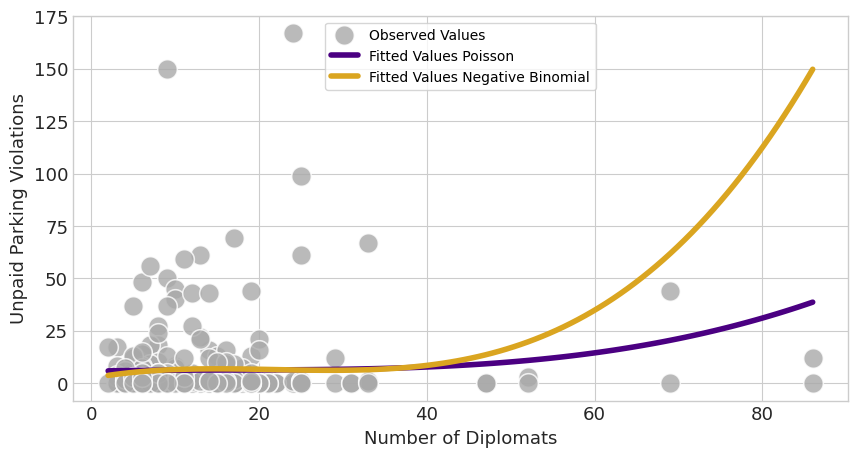

In [12]:
# Plotting predictions for the respective models above, considering only staff variable as predictor (for seeing all 
# predictors at once, we'd need a 4D-graph)

plt.figure(figsize=(10,5))
with plt.style.context('seaborn-v0_8-whitegrid'):
    sns.scatterplot(x='staff', y='violations', data=corruption_df,
                    color='darkgrey',
                    s=200, label='Observed Values', alpha=0.8)
    sns.regplot(data=corruption_df, x='staff', y='fitted_poisson', order=3,
                ci=False,
                scatter=False, color='indigo',
                label='Fitted Values Poisson',
                line_kws={'linewidth': 4})
    sns.regplot(data=corruption_df, x='staff', y='fitted_neg_binomial', order=3,
                ci=False,
                scatter = False, color='goldenrod',
                label='Fitted Values Negative Binomial',
                line_kws={'linewidth': 4})
plt.xlabel('Number of Diplomats', fontsize=13)
plt.ylabel('Unpaid Parking Violations', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(loc='upper center', fontsize=10)
plt.show()